# Graph Neural Networks (GNN) — Implementation

This notebook covers the code implementation, training, and benchmarks.
For theory and mathematical foundations see **`notebook_theory.ipynb`**.

**Files:**
```
model.py   — TSPGNN architecture
data.py    — data helpers and dataset loader
train.py   — training loop (run from terminal)
```


In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                     MODEL CONFIGURATION                             ║
# ║  Choose the size to use throughout this notebook.                   ║
# ║  Run the matching train.py command first if you haven't already.    ║
# ║                                                                      ║
# ║  Commands:                                                           ║
# ║    python train.py --size small  --steps 1000  --out model/gnn_small.pt   ║
# ║    python train.py --size medium --steps 3000  --out model/gnn_medium.pt  ║
# ║    python train.py --size large  --steps 5000  --out model/gnn_large.pt   ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Select model size ────────────────────────────────────────────────────────
#   'small'  — d=64,  L=4  (~131K params)   quick tests, n ≤ 20
#   'medium' — d=128, L=6  (~526K params)   standard TSP, n ≤ 100  ← paper default
#   'large'  — d=256, L=8  (~2.1M params)   larger instances, n ≤ 200
SIZE       = "large"
MODEL_PATH = f"model/gnn_{SIZE}.pt"

print(f"Using model: {SIZE}  →  {MODEL_PATH}")


Using model: large  →  model/gnn_large.pt


In [5]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import permutations

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from data import random_instance, tour_length, greedy_decode, optimal_tour_labels, load_cities
from model import TSPGNN, MODEL_SIZES

print('Modules imported successfully.')
print('\nParameter counts per preset:')
for size, (d, L) in MODEL_SIZES.items():
    n_params = sum(p.numel() for p in TSPGNN(d=d, L=L).parameters())
    print(f'  {size:<8} d={d:>3}, L={L}  →  {n_params:>10,} parameters')


Modules imported successfully.

Parameter counts per preset:
  small    d= 64, L=4  →      85,637 parameters
  medium   d=128, L=6  →     504,327 parameters
  large    d=256, L=8  →   2,665,993 parameters


## 7. Implementation

## 8. Demonstration

> The model is trained externally via `train.py`. Run one of the commands below
> from the `DL_MODEL/gnn/` directory, then execute the cells below to load the
> saved model and visualise the result.

```bash
# Quick test (small model, synthetic coords)
python train.py --size small --steps 500

# Better results (paper default)
python train.py --size medium --steps 2000 --source tsp

# Best results, slower to train
python train.py --size large --steps 5000 --source tsp

# Fine-tune an existing model on a different dataset
python train.py --resume model/gnn.pt --size medium --source solomon --steps 500 --lr 1e-4
```


Loaded large model (2,665,993 params) — 1000 training steps, best loss 0.0832
Optimal tour length : 2.1586
GNN greedy tour     : 2.1586  (optimality gap = 0.0 %)


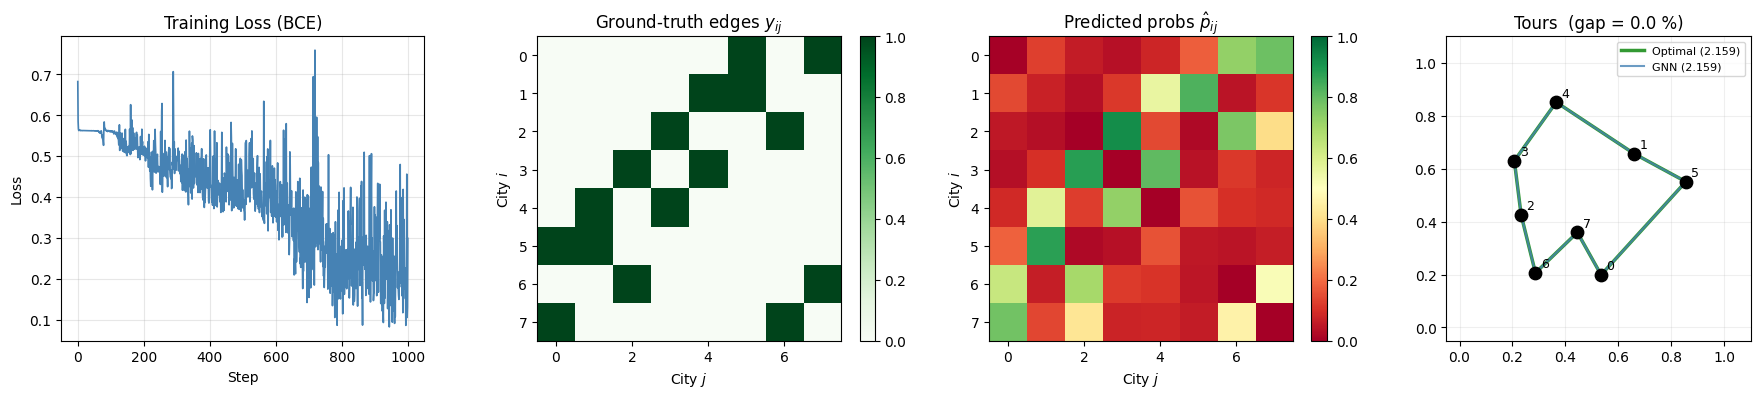


GNN tour : 0 → 7 → 6 → 2 → 3 → 4 → 1 → 5 → 0
Optimal  : 0 → 5 → 1 → 4 → 3 → 2 → 6 → 7 → 0


In [6]:
# ── Load trained model (SIZE and MODEL_PATH set in config cell) ──────────────
from model import MODEL_SIZES

D, L_GNN = MODEL_SIZES[SIZE]
model_demo = TSPGNN(d=D, L=L_GNN)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"{MODEL_PATH} not found — run train.py first.")

model_demo.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
model_demo.eval()
losses = np.load('model/losses.npy').tolist()
print(f'Loaded {SIZE} model ({sum(p.numel() for p in model_demo.parameters()):,} params)'
      f' — {len(losses)} training steps, best loss {min(losses):.4f}')

# ── Inference on one held-out instance ───────────────────────────────────────
N_DEMO = 8
torch.manual_seed(7)
coords = random_instance(N_DEMO)
y_true = optimal_tour_labels(coords)

with torch.no_grad():
    p_hat = model_demo(coords)

tour       = greedy_decode(p_hat)
length_gnn = tour_length(coords, tour)

best_len, best_tour = float('inf'), None
for perm in permutations(range(1, N_DEMO)):
    t = [0] + list(perm)
    l = tour_length(coords, t)
    if l < best_len:
        best_len, best_tour = l, t

gap = (length_gnn - best_len) / best_len * 100
print(f'Optimal tour length : {best_len:.4f}')
print(f'GNN greedy tour     : {length_gnn:.4f}  (optimality gap = {gap:.1f} %)')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(losses, color='steelblue', lw=1.2)
axes[0].set_title('Training Loss (BCE)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

im0 = axes[1].imshow(y_true.numpy(), cmap='Greens', vmin=0, vmax=1)
axes[1].set_title('Ground-truth edges $y_{ij}$')
axes[1].set_xlabel('City $j$')
axes[1].set_ylabel('City $i$')
plt.colorbar(im0, ax=axes[1], fraction=0.046)

im1 = axes[2].imshow(p_hat.numpy(), cmap='RdYlGn', vmin=0, vmax=1)
axes[2].set_title('Predicted probs $\\hat{p}_{ij}$')
axes[2].set_xlabel('City $j$')
axes[2].set_ylabel('City $i$')
plt.colorbar(im1, ax=axes[2], fraction=0.046)

xy = coords.numpy()

def draw_tour(ax, xy, tour, color, lw, label):
    tc = tour + [tour[0]]
    for k in range(len(tc) - 1):
        a, b = tc[k], tc[k + 1]
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=color, lw=lw, alpha=0.8, label=label if k == 0 else None)

draw_tour(axes[3], xy, best_tour, 'green',     2.5, f'Optimal ({best_len:.3f})')
draw_tour(axes[3], xy, tour,      'steelblue', 1.5, f'GNN ({length_gnn:.3f})')
axes[3].scatter(xy[:, 0], xy[:, 1], s=80, zorder=5, color='black')
for i, (xi, yi) in enumerate(xy):
    axes[3].annotate(str(i), (xi + 0.02, yi + 0.02), fontsize=9)
axes[3].set_title(f'Tours  (gap = {gap:.1f} %)')
axes[3].set_xlim(-0.05, 1.10)
axes[3].set_ylim(-0.05, 1.10)
axes[3].set_aspect('equal')
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print(f'\nGNN tour : {" → ".join(map(str, tour + [tour[0]]))}')
print(f'Optimal  : {" → ".join(map(str, best_tour + [best_tour[0]]))}')


## 9. Benchmark

> Inference time and memory footprint vs. instance size — untrained model (random weights).

### What is measured

| Metric | Description |
|--------|-------------|
| **Inference time (ms)** | Time for one forward pass + greedy decode, averaged over 20 repetitions |
| **Edge memory (MB)** | Size of the edge embedding tensor $\mathbf{E} \in \mathbb{R}^{n \times n \times d}$ with $d=128$, in float32 |

Note: the model uses **random weights** — this isolates the computational cost from solution quality.

---

### How to read the 3 plots

| Plot | What to look for |
|------|------------------|
| **Inference Time** | Should grow quadratically with $n$ — each additional city adds $n$ new edges to process. |
| **Log-log Scaling** | The measured curve should follow the $O(n^2)$ reference line. A steeper slope would indicate a hidden $O(n^3)$ term. |
| **Memory Footprint** | Grows as $n^2 \cdot d \cdot 4$ bytes. At $n=200$, $d=128$: $200^2 \times 128 \times 4 = 20.5$ MB — manageable. At $n=1000$: $\approx 512$ MB per instance — problematic for batch training. |

---

### Practical limits

| $n$ | Edge memory ($d=128$) | Feasible? |
|-----|----------------------|-----------|
| 50  | ~1.3 MB | Yes |
| 100 | ~5.1 MB | Yes |
| 200 | ~20.5 MB | Yes |
| 500 | ~128 MB | Marginal |
| 1000 | ~512 MB | No (OOM on most GPUs) |

Beyond $n \approx 300$, a **sparse $k$-NN graph** (keep only the $k=10$ nearest neighbors per node) reduces memory to $O(k \cdot n \cdot d)$ — linear in $n$ — at the cost of some solution quality.

     n   mean (ms)   std (ms)   edge mem (MB)
----------------------------------------------
    10       35.66      22.39             0.1
    20       36.26      10.04             0.4
    50      173.06     131.67             2.6
   100      235.29     110.63            10.2
   200      881.65     209.95            41.0


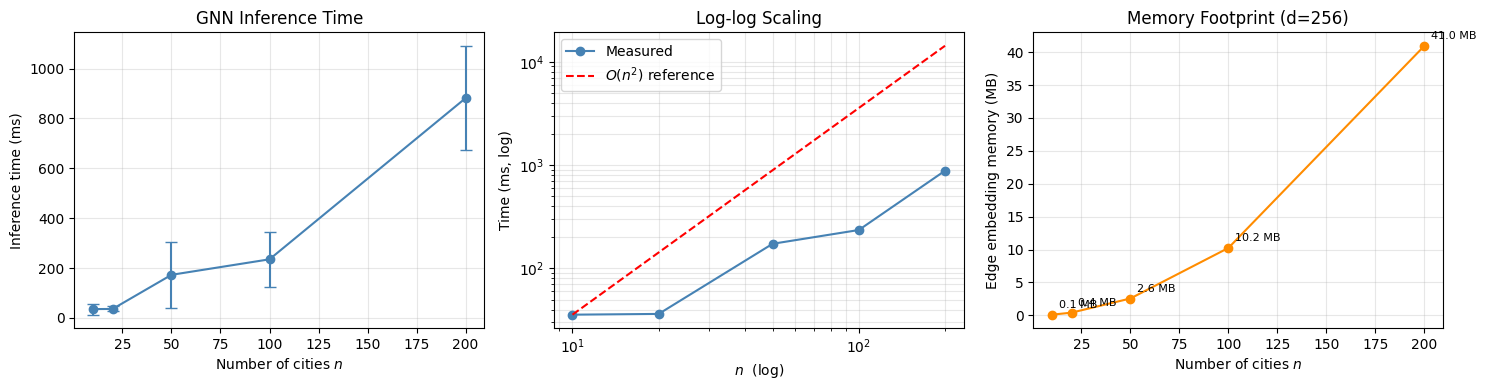


Summary — TSPGNN large (d=256, L=8)
     n     time (ms)    edge mem     feasible?
-----------------------------------------------
    10       35.66ms       0.1MB           yes
    20       36.26ms       0.4MB           yes
    50      173.06ms       2.6MB           yes
   100      235.29ms      10.2MB           yes
   200      881.65ms      41.0MB           yes


In [7]:
# ── Benchmark: inference time and memory vs. instance size ───────────────────
# Uses the selected model size from the config cell.
# Note: benchmarks inference speed only — model may be untrained.

model_bench = TSPGNN(d=D, L=L_GNN).eval()

BENCH_SIZES = [10, 20, 50, 100, 200]
N_REPS      = 20
results     = {}

print(f"{'n':>6}  {'mean (ms)':>10}  {'std (ms)':>9}  {'edge mem (MB)':>14}")
print('-' * 46)

with torch.no_grad():
    for n in BENCH_SIZES:
        times = []
        for _ in range(N_REPS):
            x  = random_instance(n)
            t0 = time.perf_counter()
            p  = model_bench(x)
            _g = greedy_decode(p)
            times.append(time.perf_counter() - t0)
        mean_ms = np.mean(times) * 1e3
        std_ms  = np.std(times)  * 1e3
        edge_mb = n * n * D * 4 / 1e6
        results[n] = {'mean_ms': mean_ms, 'std_ms': std_ms, 'edge_mb': edge_mb}
        print(f'{n:>6}  {mean_ms:>10.2f}  {std_ms:>9.2f}  {edge_mb:>14.1f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ns    = BENCH_SIZES
means = [results[n]['mean_ms'] for n in ns]
stds  = [results[n]['std_ms']  for n in ns]
mems  = [results[n]['edge_mb'] for n in ns]

axes[0].errorbar(ns, means, yerr=stds, marker='o', capsize=4, color='steelblue')
axes[0].set_xlabel('Number of cities $n$')
axes[0].set_ylabel('Inference time (ms)')
axes[0].set_title('GNN Inference Time')
axes[0].grid(True, alpha=0.3)

ns_arr = np.array(ns, dtype=float)
ref_n2 = means[0] * (ns_arr / ns_arr[0]) ** 2
axes[1].loglog(ns_arr, means,  'o-', color='steelblue', label='Measured')
axes[1].loglog(ns_arr, ref_n2, 'r--',                   label=r'$O(n^2)$ reference')
axes[1].set_xlabel('$n$  (log)')
axes[1].set_ylabel('Time (ms, log)')
axes[1].set_title('Log-log Scaling')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

axes[2].plot(ns, mems, 'o-', color='darkorange')
axes[2].set_xlabel('Number of cities $n$')
axes[2].set_ylabel('Edge embedding memory (MB)')
axes[2].set_title(f'Memory Footprint (d={D})')
axes[2].grid(True, alpha=0.3)
for n, m in zip(ns, mems):
    axes[2].annotate(f'{m:.1f} MB', (n, m), textcoords='offset points',
                     xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nSummary — TSPGNN {SIZE} (d={D}, L={L_GNN})')
print(f"{'n':>6}  {'time (ms)':>12}  {'edge mem':>10}  {'feasible?':>12}")
print('-' * 47)
for n in BENCH_SIZES:
    r = results[n]
    feasible = 'yes' if r['edge_mb'] < 500 else 'no (OOM risk)'
    print(f"{n:>6}  {r['mean_ms']:>10.2f}ms  {r['edge_mb']:>8.1f}MB  {feasible:>12}")


## 9b. Solution Quality on Real Dataset

> Tests the **trained model** on instances loaded from the CSV dataset.
> Each instance is compared against a **nearest-neighbour (NN) baseline** — a fast
> classical heuristic that greedily visits the closest unvisited city.

### Metrics

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Tour length** | $\sum_{k} d(c_k, c_{k+1})$ | Total Euclidean distance of the decoded tour |
| **Gap vs NN** | $\frac{L_{GNN} - L_{NN}}{L_{NN}} \times 100\%$ | Relative difference; negative = GNN beats NN |
| **Win rate** | $\frac{\#\{L_{GNN} \le L_{NN}\}}{N}$ | Fraction of instances where GNN is better or equal |

> **Note:** run `python train.py` from `DL_MODEL/gnn/` before executing this cell
> to generate `model/gnn.pt`. If the file is missing, the cell falls back to random weights.


Loaded weights from model/gnn_large.pt
  n=  10  shape=(10, 2)  range=[0.000, 1.000]
  n=  50  shape=(50, 2)  range=[0.000, 1.000]
  n= 100  shape=(100, 2)  range=[0.000, 1.000]
  n= 200  shape=(200, 2)  range=[0.000, 1.000]

     n    GNN tour     NN tour     gap %  better
------------------------------------------------
    10      3.8056      4.4134    -13.77%     GNN
    50      7.9144      7.5857     +4.33%     NN 
   100     10.0665      9.5817     +5.06%     NN 
   200     15.0413     13.9632     +7.72%     NN 


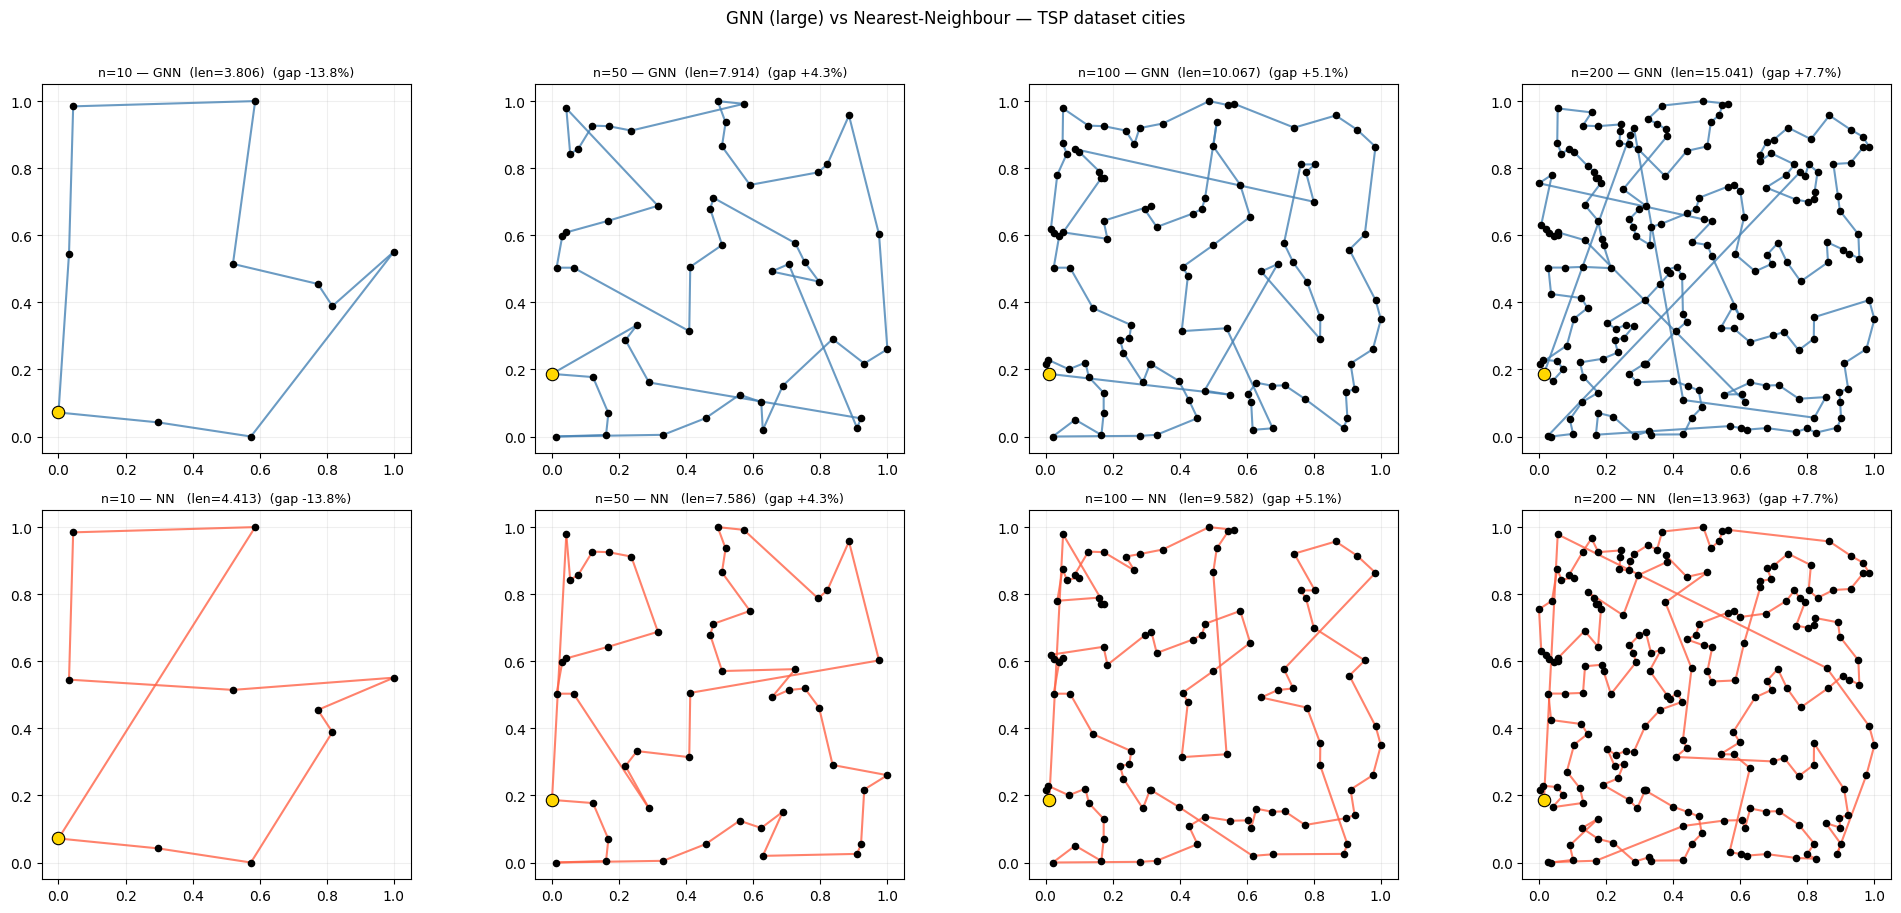

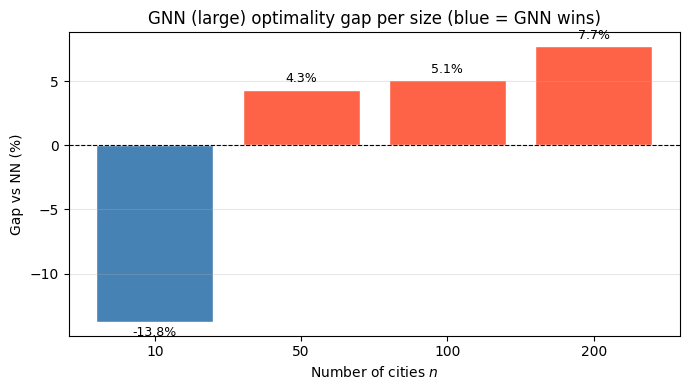

In [8]:
# ── Load trained model (SIZE and MODEL_PATH from config cell) ────────────────
model_test = TSPGNN(d=D, L=L_GNN)
if os.path.exists(MODEL_PATH):
    model_test.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
    print(f'Loaded weights from {MODEL_PATH}')
else:
    print(f'WARNING: {MODEL_PATH} not found — using random weights')
model_test.eval()

# ── Load cities from dataset ──────────────────────────────────────────────────
EVAL_SIZES = [10, 50, 100, 200]
instances  = []
for n in EVAL_SIZES:
    coords = load_cities(n, source='tsp')
    instances.append({'n': n, 'coords': coords})
    print(f'  n={n:>4}  shape={tuple(coords.shape)}  '
          f'range=[{coords.min():.3f}, {coords.max():.3f}]')

# ── Nearest-neighbour baseline ────────────────────────────────────────────────
def nearest_neighbour_tour(coords: torch.Tensor, start: int = 0) -> list:
    n = coords.shape[0]
    visited = torch.zeros(n, dtype=torch.bool)
    tour    = [start]
    visited[start] = True
    for _ in range(n - 1):
        dists = torch.cdist(coords[tour[-1]].unsqueeze(0), coords).squeeze(0)
        dists[visited] = float('inf')
        tour.append(dists.argmin().item())
        visited[tour[-1]] = True
    return tour

# ── Inference on each size ────────────────────────────────────────────────────
records = []
with torch.no_grad():
    for inst in instances:
        coords   = inst['coords']
        p_hat    = model_test(coords)
        gnn_tour = greedy_decode(p_hat)
        nn_tour  = nearest_neighbour_tour(coords)
        gnn_len  = tour_length(coords, gnn_tour)
        nn_len   = tour_length(coords, nn_tour)
        gap      = (gnn_len - nn_len) / nn_len * 100
        records.append({
            'n': inst['n'], 'coords': coords,
            'gnn_tour': gnn_tour, 'nn_tour': nn_tour,
            'gnn': gnn_len, 'nn': nn_len, 'gap': gap,
        })

# ── Results table ─────────────────────────────────────────────────────────────
print(f"\n{'n':>6}  {'GNN tour':>10}  {'NN tour':>10}  {'gap %':>8}  {'better':>6}")
print('-' * 48)
for r in records:
    better = 'GNN' if r['gnn'] <= r['nn'] else 'NN '
    print(f"{r['n']:>6}  {r['gnn']:>10.4f}  {r['nn']:>10.4f}  {r['gap']:>+8.2f}%  {better:>6}")

# ── Tour visualisation — one panel per size ───────────────────────────────────
fig, axes = plt.subplots(2, len(records), figsize=(5 * len(records), 9))

def plot_tour(ax, xy, tour, color, lw, label):
    closed = tour + [tour[0]]
    for k in range(len(closed) - 1):
        a, b = closed[k], closed[k + 1]
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=color, lw=lw, alpha=0.8,
                label=label if k == 0 else None)

for col, r in enumerate(records):
    xy = r['coords'].numpy()
    for row, (tour, color, title) in enumerate([
        (r['gnn_tour'], 'steelblue', f"GNN  (len={r['gnn']:.3f})"),
        (r['nn_tour'],  'tomato',    f"NN   (len={r['nn']:.3f})"),
    ]):
        ax = axes[row][col]
        plot_tour(ax, xy, tour, color=color, lw=1.5, label=title)
        ax.scatter(xy[:, 0], xy[:, 1], s=20, zorder=5, color='black')
        ax.scatter(xy[0, 0], xy[0, 1], s=80, zorder=6, color='gold',
                   edgecolors='black', linewidths=0.8)
        ax.set_title(f"n={r['n']} — {title}  (gap {r['gap']:+.1f}%)", fontsize=9)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)

fig.suptitle(f'GNN ({SIZE}) vs Nearest-Neighbour — TSP dataset cities',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
gaps   = [r['gap'] for r in records]
colors = ['steelblue' if g <= 0 else 'tomato' for g in gaps]
bars   = ax.bar([str(r['n']) for r in records], gaps, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.bar_label(bars, fmt='%.1f%%', fontsize=9, padding=3)
ax.set_xlabel('Number of cities $n$')
ax.set_ylabel('Gap vs NN (%)')
ax.set_title(f'GNN ({SIZE}) optimality gap per size (blue = GNN wins)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
